In [1]:
""" DATA LOADING """

' DATA LOADING '

In [2]:
# Importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
# fetching Files from Apple Historical Stock data
import yfinance as yf


# Download Apple Stock Data
df=yf.download("AAPL",
              start="2021-06-09",
              end="2026-06-09")
              
# save to CSV 
df.to_csv("AAPL.csv")

              
print(df.head()) # view first 5 records            


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
2021-06-10  122.925972  124.953458  122.760266  123.812992  71186400
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500
2021-06-15  126.366837  127.302605  126.123149  126.659265  62746300


In [4]:
# Load the data
df = pd.read_csv('AAPL.csv') #, skiprows=[1])
df = df.copy() # Make a copy of the original file

In [5]:
""" DATA EXPLORATION """

' DATA EXPLORATION '

In [6]:
# See file information
print(df.info())



"""The're 1004 rrecords counting from 0-1003
And the total non-null value is 1002, meaning a record is empty."""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1257 non-null   object
 1   Close   1256 non-null   object
 2   High    1256 non-null   object
 3   Low     1256 non-null   object
 4   Open    1256 non-null   object
 5   Volume  1256 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB
None


"The're 1004 rrecords counting from 0-1003\nAnd the total non-null value is 1002, meaning a record is empty."

In [7]:
# View the empty record
print(df[df.isna().any(axis=1)])

  Price Close High  Low Open Volume
1  Date   NaN  NaN  NaN  NaN    NaN


In [8]:
# See data statitsics summary
print(df.describe())

             Price               Close               High                Low  \
count         1257                1256               1256               1256   
unique        1257                1240               1256               1256   
top     2026-06-08  161.27288818359375  317.3999938964844  301.1700134277344   
freq             1                   2                  1                  1   

                    Open    Volume  
count               1256      1256  
unique              1256      1255  
top     308.739990234375  90956700  
freq                   1         2  


In [9]:
# Check Datatype for each col
print(df.dtypes)

Price     object
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object


In [10]:
# Check Series ( columns in Pandas )
print(df.columns)

""" There's a problem in the col. to be cleansed """

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


" There's a problem in the col. to be cleansed "

In [11]:
# See entire data
#print(df.to_string())

In [12]:
""" DATA CLEANING """

' DATA CLEANING '

In [13]:
# Maintain Column Header and drop null value
df.columns = df.columns.get_level_values(0)
print(df.info())
df = df.iloc[2:].reset_index(drop=True)  # Run this cell only once because of this code, because as you keep on executing it, it keeps on deleting data.

#Confirm
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1257 non-null   object
 1   Close   1256 non-null   object
 2   High    1256 non-null   object
 3   Low     1256 non-null   object
 4   Open    1256 non-null   object
 5   Volume  1256 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1255 non-null   object
 1   Close   1255 non-null   object
 2   High    1255 non-null   object
 3   Low     1255 non-null   object
 4   Open    1255 non-null   object
 5   Volume  1255 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB
None


In [14]:
# Change Price name to Date
df.rename(columns = {df.columns[0]: 'Date'}, inplace=True) # change col name from price to date

# Confirm
print(df.head())


         Date               Close                High                 Low  \
0  2021-06-09  123.92020416259766  124.52455300706954  123.32560491924683   
1  2021-06-10  122.92597198486328  124.95345787476269   122.7602659341765   
2  2021-06-11   124.1346664428711  124.22239799050632  122.91622643570359   
3  2021-06-14  127.18563079833984  127.24411353581664  123.86173050218788   
4  2021-06-15  126.36683654785156  127.30260492232891  126.12314857125716   

                 Open    Volume  
0  123.99818609803275  56877900  
1  123.81299241371467  71186400  
2  123.33537009563992  53522400  
3  124.59279446771667  96906500  
4  126.65926509447159  62746300  


In [15]:
# Check Colunm and dataype
print(df.dtypes)

Date      object
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object


In [16]:
# Change date datatype from obvject to datetime and others
df['Date'] = pd.to_datetime(df['Date'])
numeric_cols = ['Close','High','Low','Open','Volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].round(2)
    

#confirm
print(df.dtypes)

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object


In [17]:
# SET DATE AS INDEX SO THAT TIME SERIES WILL BE ABLE TO TRACK TIME AND DATE ACCORDINGLY
df.set_index("Date", inplace=True)  # Avoid rerunning

In [18]:

" No Empty value again"
df.isnull().sum()


Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [19]:
print(df.head())
print(df.info())

                 Close        High         Low        Open    Volume
Date                                                                
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
2021-06-10  122.925972  124.953458  122.760266  123.812992  71186400
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500
2021-06-15  126.366837  127.302605  126.123149  126.659265  62746300
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-09 to 2026-06-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1255 non-null   float64
 1   High    1255 non-null   float64
 2   Low     1255 non-null   float64
 3   Open    1255 non-null   float64
 4   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB
None


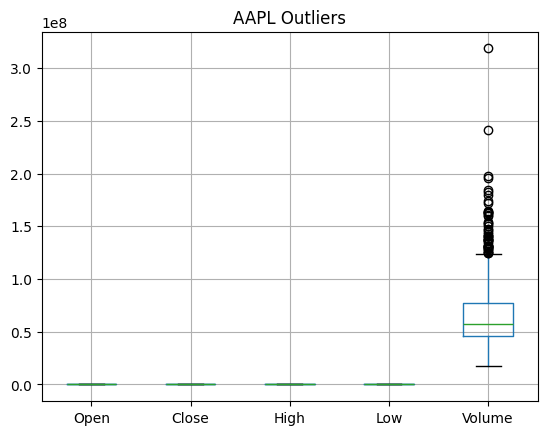

In [20]:
# Check Outliers
df[["Open", "Close", "High", "Low", "Volume"]].boxplot()
plt.title("AAPL Outliers")
plt.show()

In [21]:
# Check Outliers individually
for col in ["Open", "Close", "High", "Low", "Volume"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75) 
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} has {len(outliers)} Outliers")
    #print(outliers)

Open has 0 Outliers
Close has 0 Outliers
High has 0 Outliers
Low has 0 Outliers
Volume has 47 Outliers


In [22]:
# Sort values according to date
df = df.sort_values('Date')
print(df.head())
print(df.info())


                 Close        High         Low        Open    Volume
Date                                                                
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
2021-06-10  122.925972  124.953458  122.760266  123.812992  71186400
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500
2021-06-15  126.366837  127.302605  126.123149  126.659265  62746300
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-09 to 2026-06-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1255 non-null   float64
 1   High    1255 non-null   float64
 2   Low     1255 non-null   float64
 3   Open    1255 non-null   float64
 4   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB
None


In [23]:
""" DATA TRANSFORMATION """

' DATA TRANSFORMATION '

In [24]:
# Create custom cols
df["Daily Price Change"] = (df["Close"] - df["Open"]).round(2)
df["DPC %"] = ((df["Daily Price Change"]/df["Open"]) * 100).round(2)
    # Extract dates...
# instead of using df["Date"] use df.index because date is now index
#df["Year"] = (df["Date"].dt.year)
df['Year'] = df.index.year
df['Month Name'] = df.index.month_name()
df['Month'] = df.index.month
df['Weekday'] = df.index.day_name()
df['Day'] = df.index.day
df['Year Month'] = pd.to_datetime(df.index.strftime('%Y-%m'))

print(df.head())

                 Close        High         Low        Open    Volume  \
Date                                                                   
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900   
2021-06-10  122.925972  124.953458  122.760266  123.812992  71186400   
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400   
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500   
2021-06-15  126.366837  127.302605  126.123149  126.659265  62746300   

            Daily Price Change  DPC %  Year Month Name  Month    Weekday  Day  \
Date                                                                            
2021-06-09               -0.08  -0.06  2021       June      6  Wednesday    9   
2021-06-10               -0.89  -0.72  2021       June      6   Thursday   10   
2021-06-11                0.80   0.65  2021       June      6     Friday   11   
2021-06-14                2.59   2.08  2021       June      6     Monday   14   
2021-06-1

In [110]:
# Financial Market Performance Indicator MPIs
monthly_close = df.groupby("Month Name")[["Close"]].mean
monthly_open = df.groupby("Month Name")["Open"].mean
monthly_volume = df.groupby("Month Name")["Volume"].mean
monthly_high = df.groupby("Month Name")["High"].mean
monthly_low = df.groupby("Month Name")["Low"].mean



yearly_close = df.groupby("Year")["Close"].mean
yearly_open = df.groupby("Year")["Open"].mean
yearly_volume = df.groupby("Year")["Volume"].mean
yearly_high = df.groupby("Year")["High"].mean
yearly_low = df.groupby("Year")["Low"].mean



print(monthly_close)

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x000001AA3E1F37F0>>


In [26]:
""" TIME SERIES ANALYSIS -  HOW DOES AAPL PERFORM OVER TIME? """

' TIME SERIES ANALYSIS -  HOW DOES AAPL PERFORM OVER TIME? '

In [27]:
# SET DATE AS INDEX SO THAT TIME SERIES WILL BE ABLE TO TRACK TIME AND DATE ACCORDINGLY
#df.set_index("Date", inplace=True)  # Avoid rerunning

In [28]:
#verify
print(df.head())

                 Close        High         Low        Open    Volume  \
Date                                                                   
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900   
2021-06-10  122.925972  124.953458  122.760266  123.812992  71186400   
2021-06-11  124.134666  124.222398  122.916226  123.335370  53522400   
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500   
2021-06-15  126.366837  127.302605  126.123149  126.659265  62746300   

            Daily Price Change  DPC %  Year Month Name  Month    Weekday  Day  \
Date                                                                            
2021-06-09               -0.08  -0.06  2021       June      6  Wednesday    9   
2021-06-10               -0.89  -0.72  2021       June      6   Thursday   10   
2021-06-11                0.80   0.65  2021       June      6     Friday   11   
2021-06-14                2.59   2.08  2021       June      6     Monday   14   
2021-06-1

In [29]:
df["Daily Return"] = df["Close"].pct_change().round(2)
monthly_returns = df["Close"].resample("ME").last().pct_change() # compare months
df["Volatility"] = df["Daily Return"].rolling(30).std().round(2) # check if the last 30 days returns are stable
df["MA_7"] = df["Close"].rolling(7).mean().round(2) # Moving Avwrage 7days
df["MA_30"] = df["Close"].rolling(30).mean().round(2) # Moving Average 30 days

print(monthly_returns)

Date
2021-06-30         NaN
2021-07-31    0.064982
2021-08-31    0.042489
2021-09-30   -0.068036
2021-10-31    0.058657
                ...   
2026-02-28    0.019066
2026-03-31   -0.039329
2026-04-30    0.069191
2026-05-31    0.151087
2026-06-30   -0.033711
Freq: ME, Name: Close, Length: 61, dtype: float64


In [30]:
# WORKS LIKE GROUP BY BECAUSE DATE IS NOW THE INDEX for all cols
yearly_avg = df.resample('YE').mean
monthly_avg = df.resample('ME').mean
quarterly_avg = df.resample('QE').mean
weekly_avg = df.resample('W').mean
# but if you want to sepcify a particular col  weekly_avg = df['col_name'].resample('W').mean

# SHARE SOLD
month_share = df["Volume"].resample("ME").sum()
year_share = df["Volume"].resample("YE").sum()

In [31]:
""" SAVE FILE """
df= df.round(2)
df.to_csv("AAPL_Cleaned.csv")

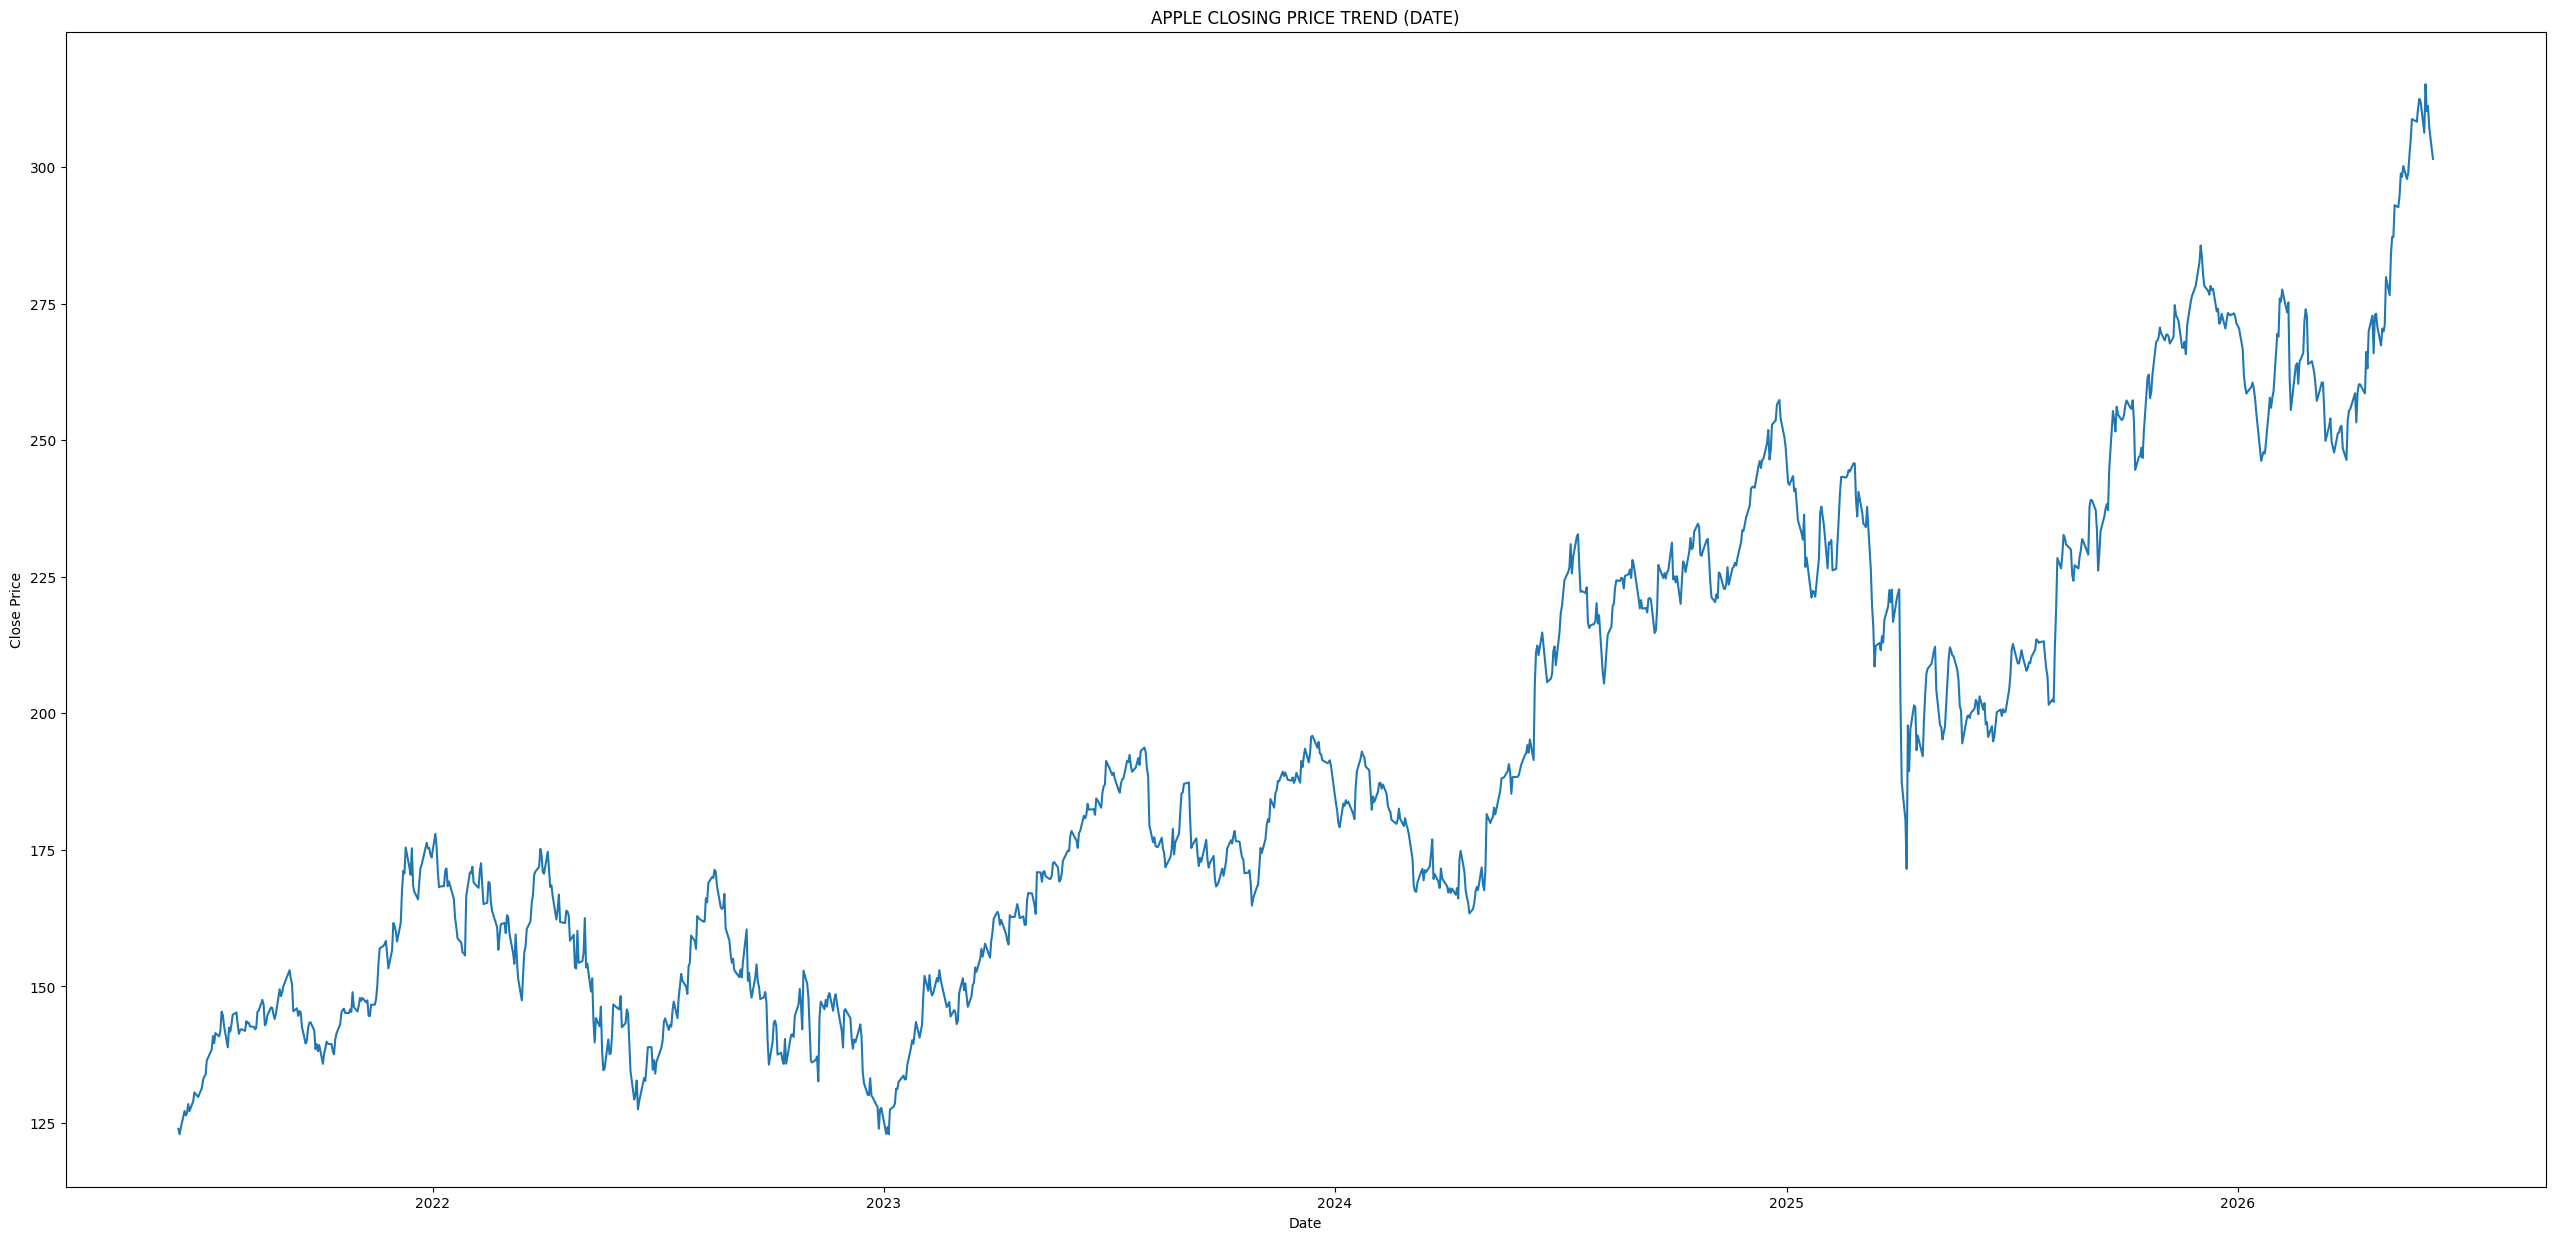

In [113]:
plt.figure(figsize=(32,15))
plt.plot(df.index, df["Close"])
plt.title("APPLE CLOSING PRICE TREND (DATE)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

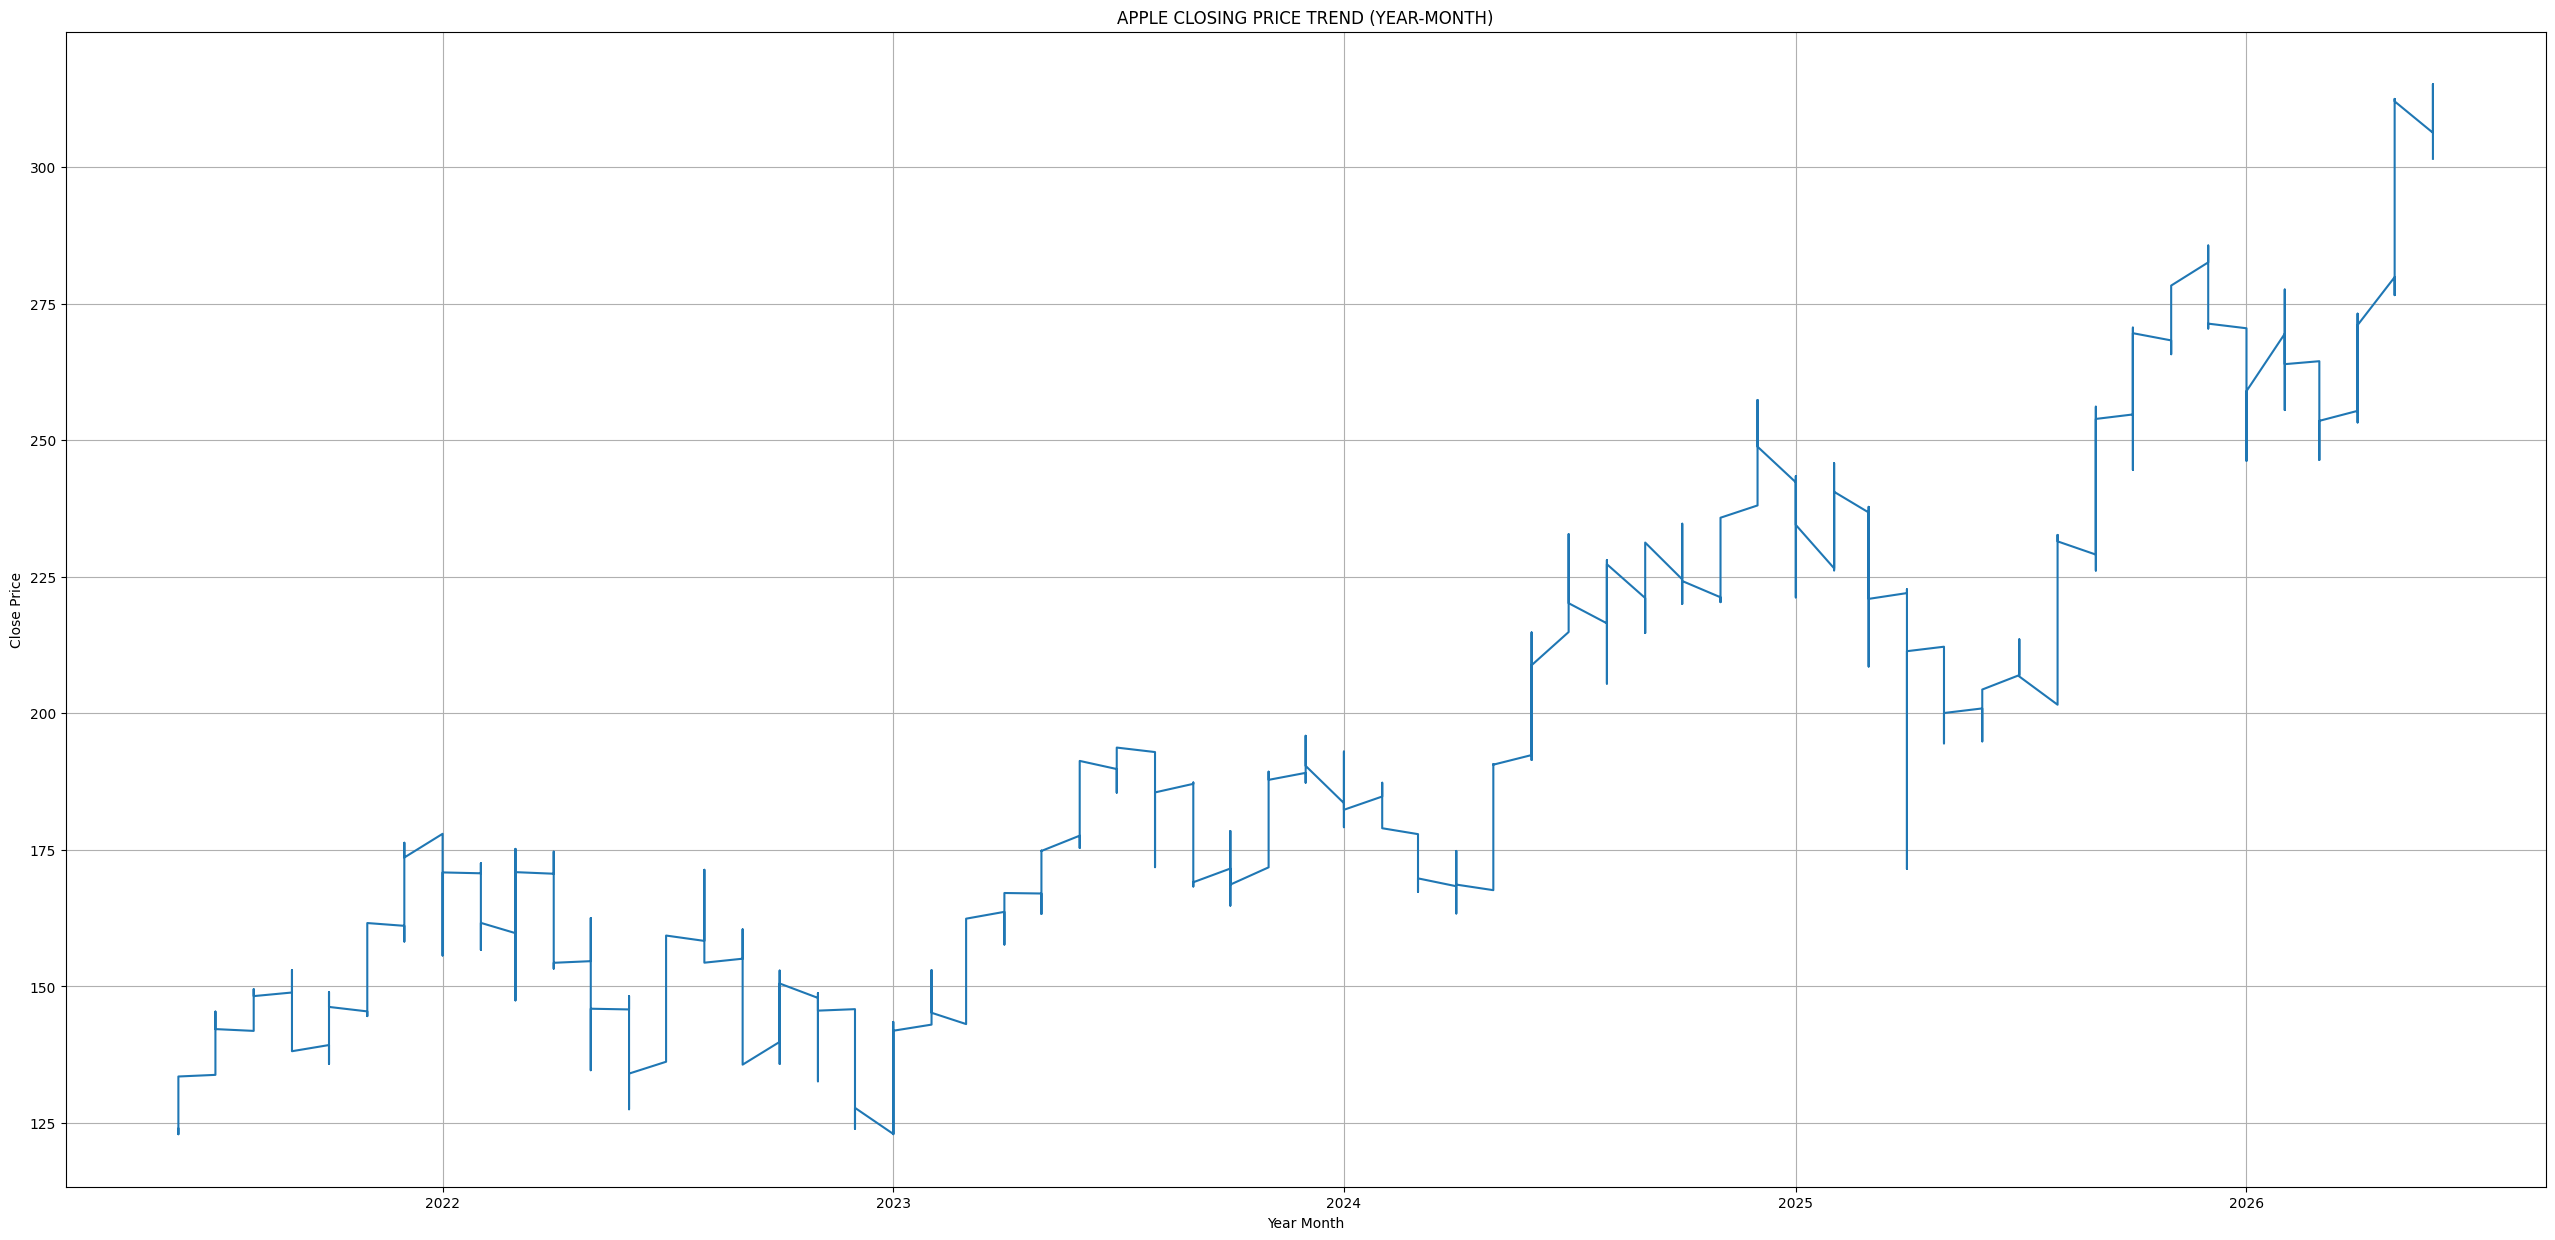

In [91]:
plt.figure(figsize=(32,15))
plt.plot(df["Year Month"], df["Close"])
plt.title("APPLE CLOSING PRICE TREND (YEAR-MONTH)")
plt.xlabel("Year Month")
plt.ylabel("Close Price")
plt.grid()
plt.show()

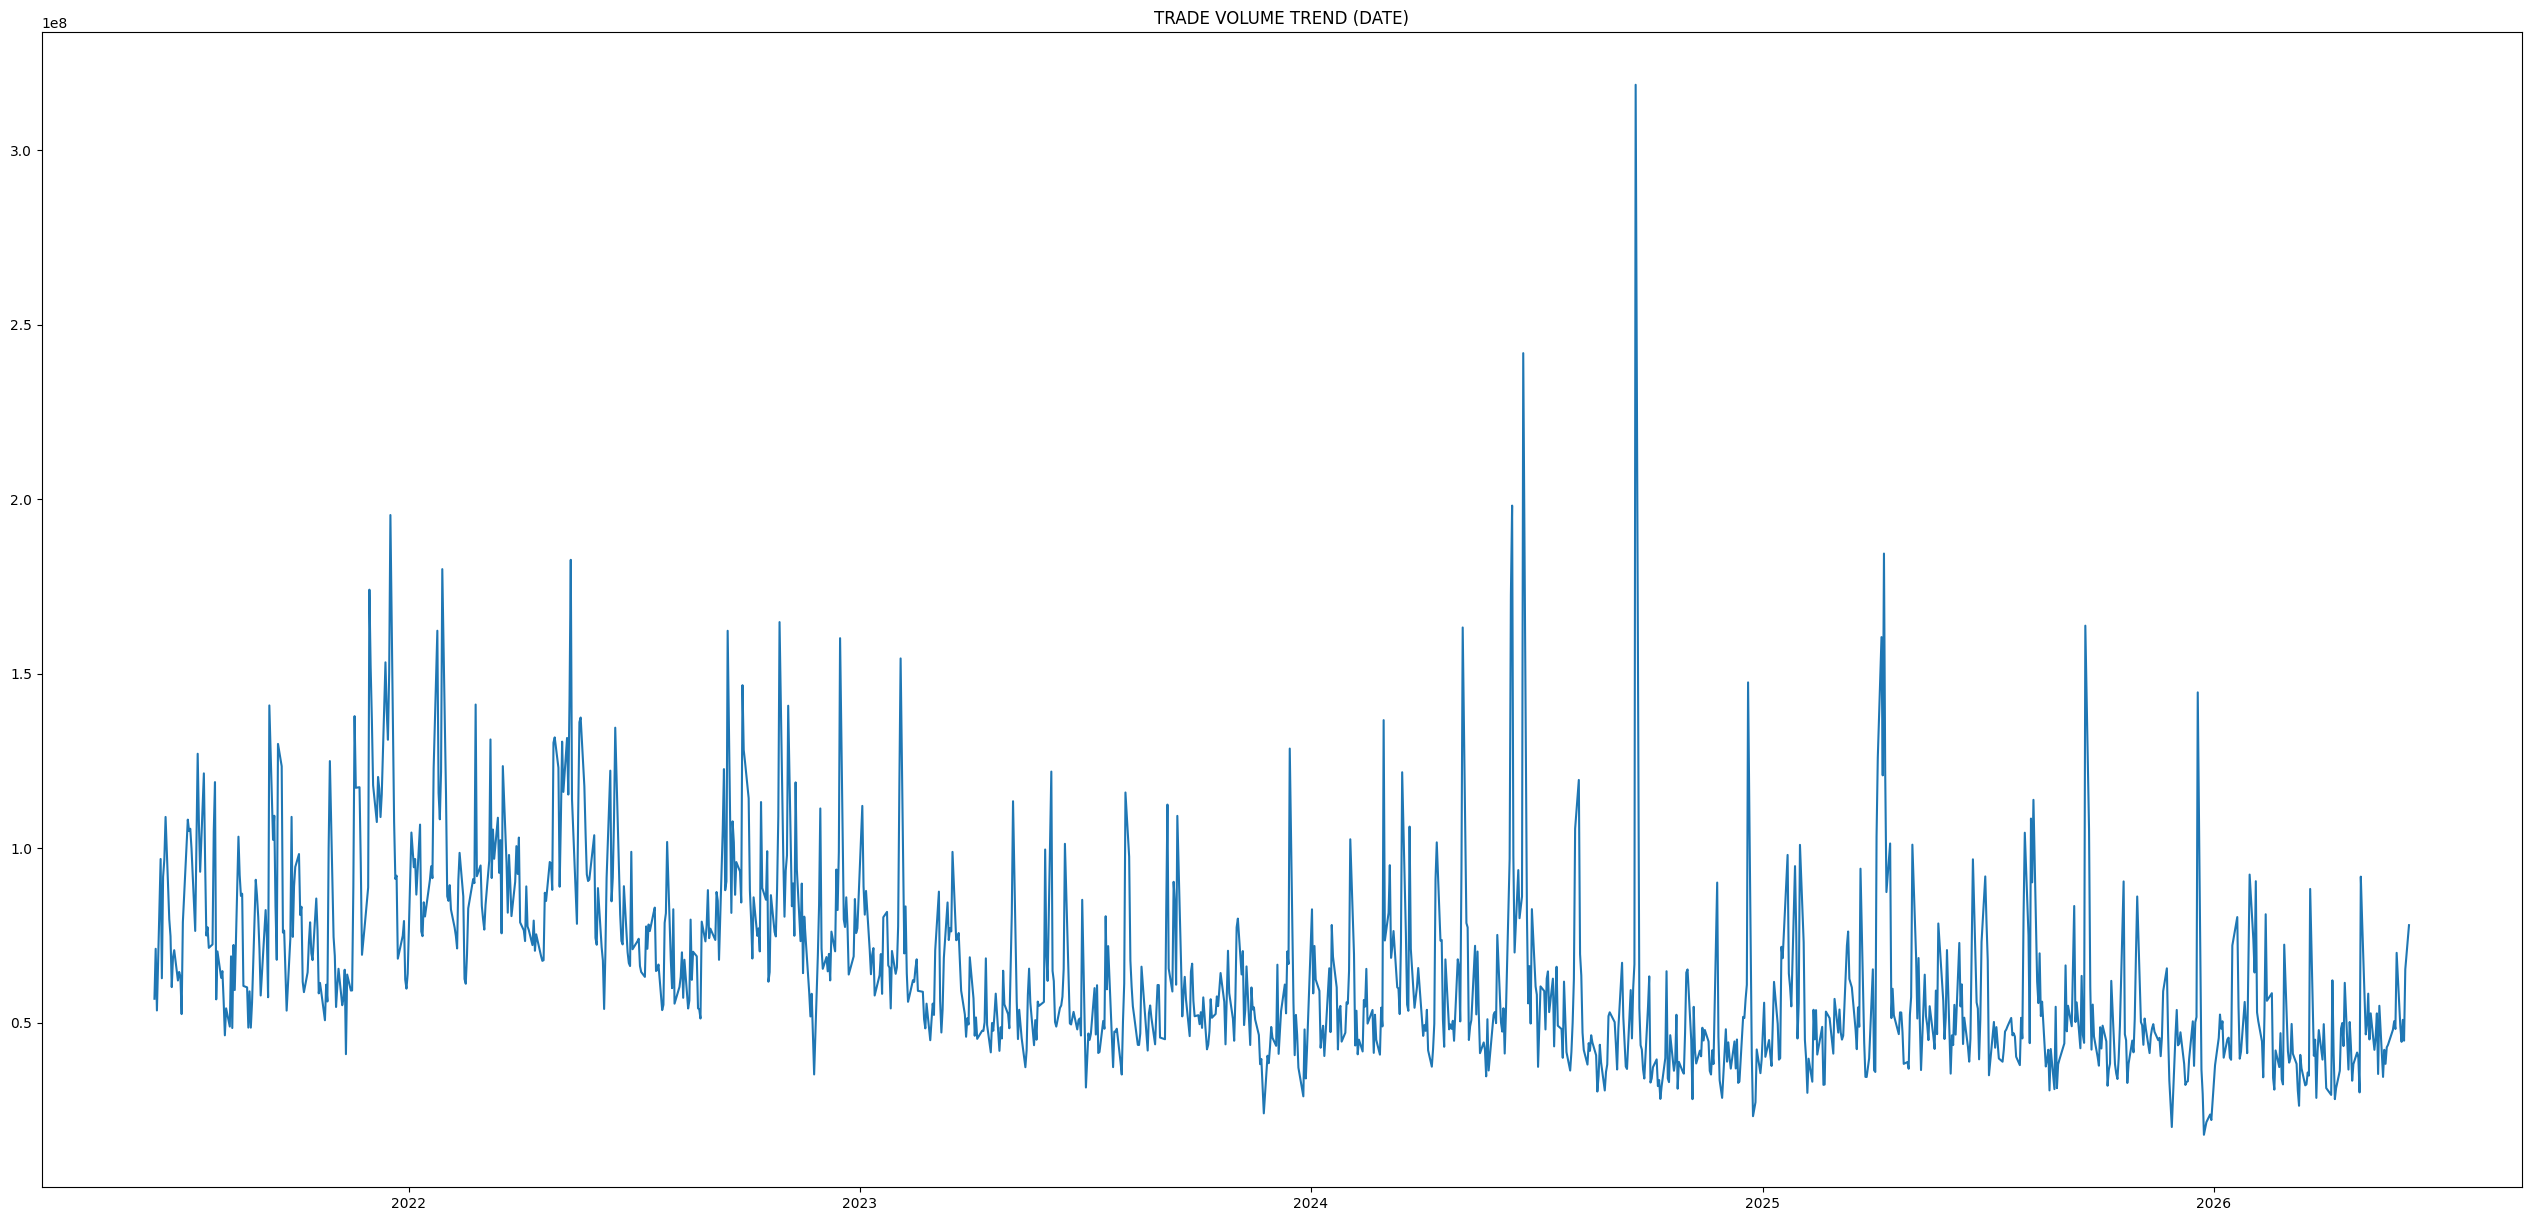

In [115]:
plt.figure(figsize=(32,15))
plt.plot(df.index, df["Volume"])
plt.title("TRADE VOLUME TREND (DATE)")
plt.show()

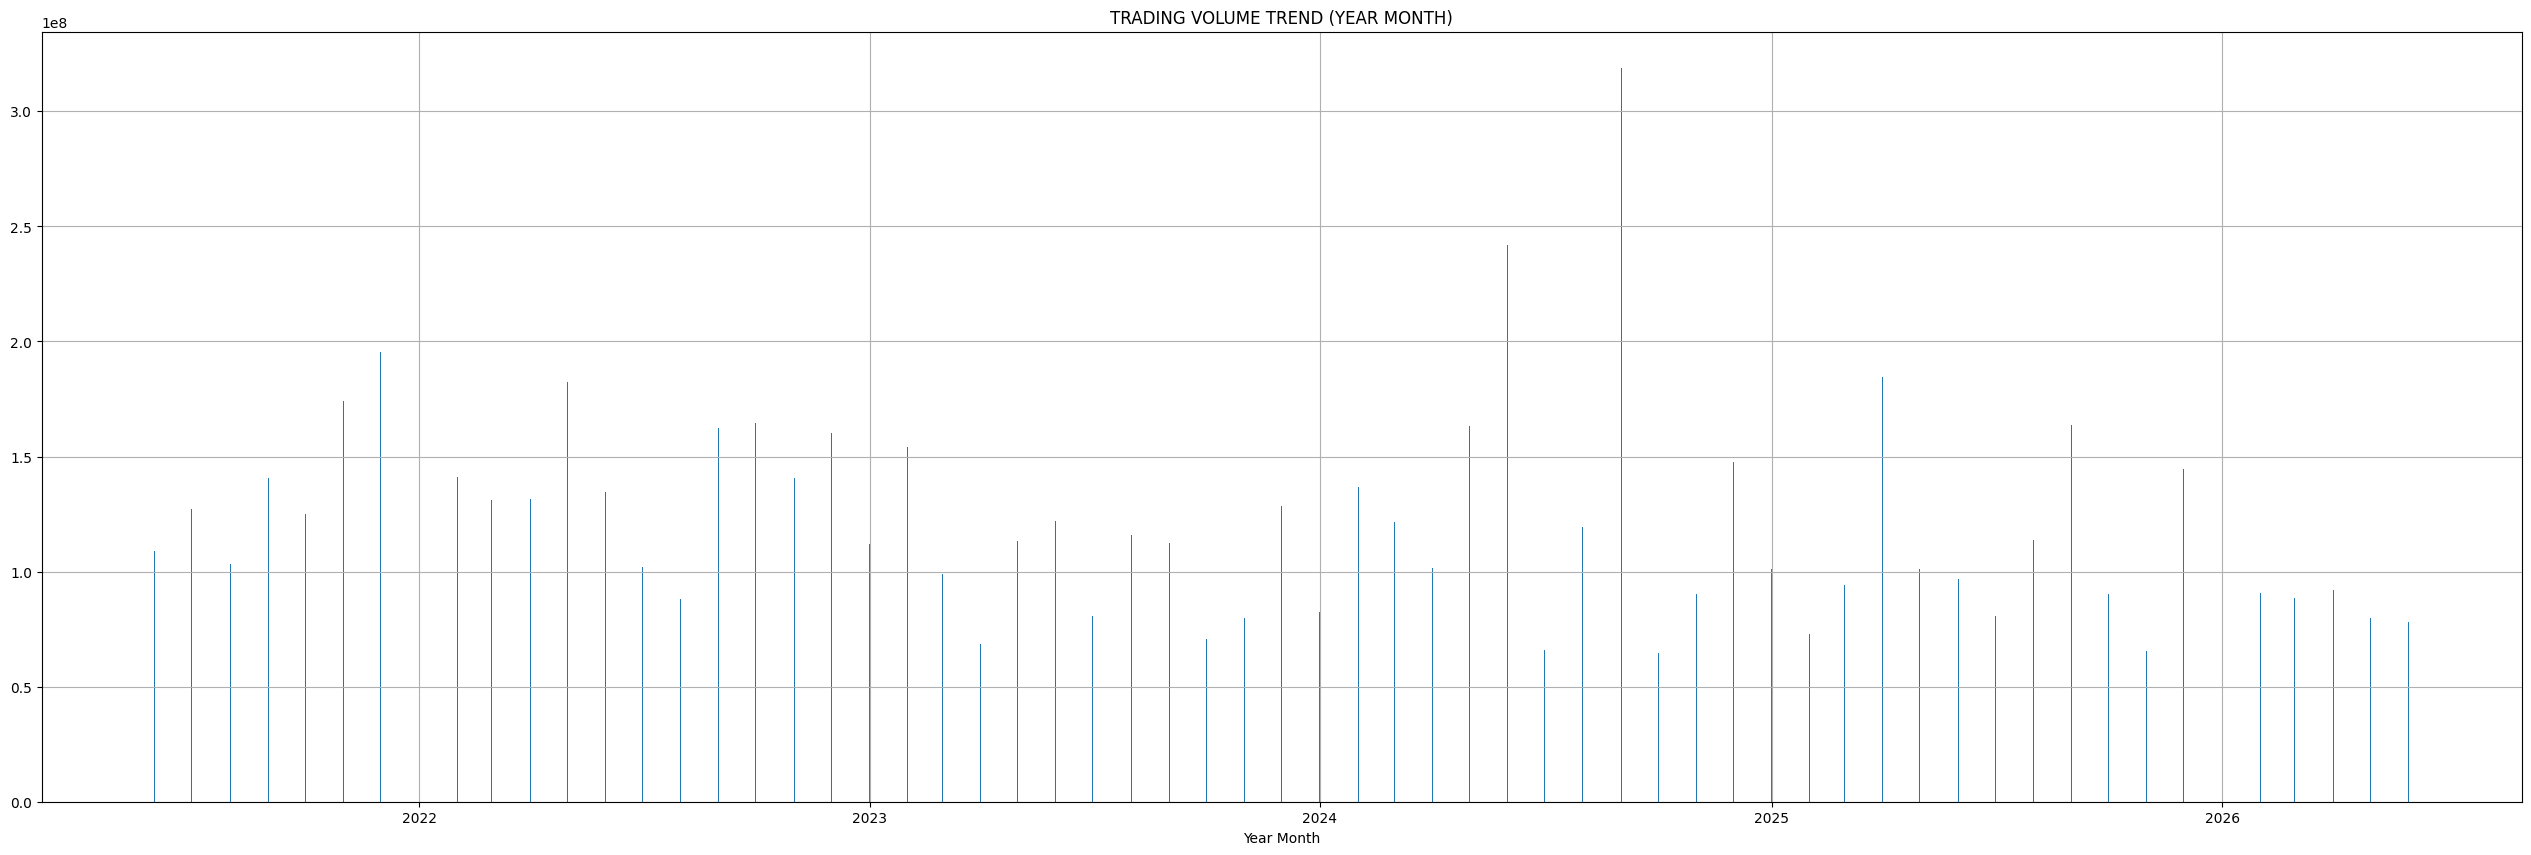

In [78]:
plt.figure(figsize=(32,10))
plt.bar(df["Year Month"], df["Volume"])
plt.title("TRADING VOLUME TREND (YEAR MONTH)")
plt.xlabel("Year Month")
plt.grid()
plt.show()

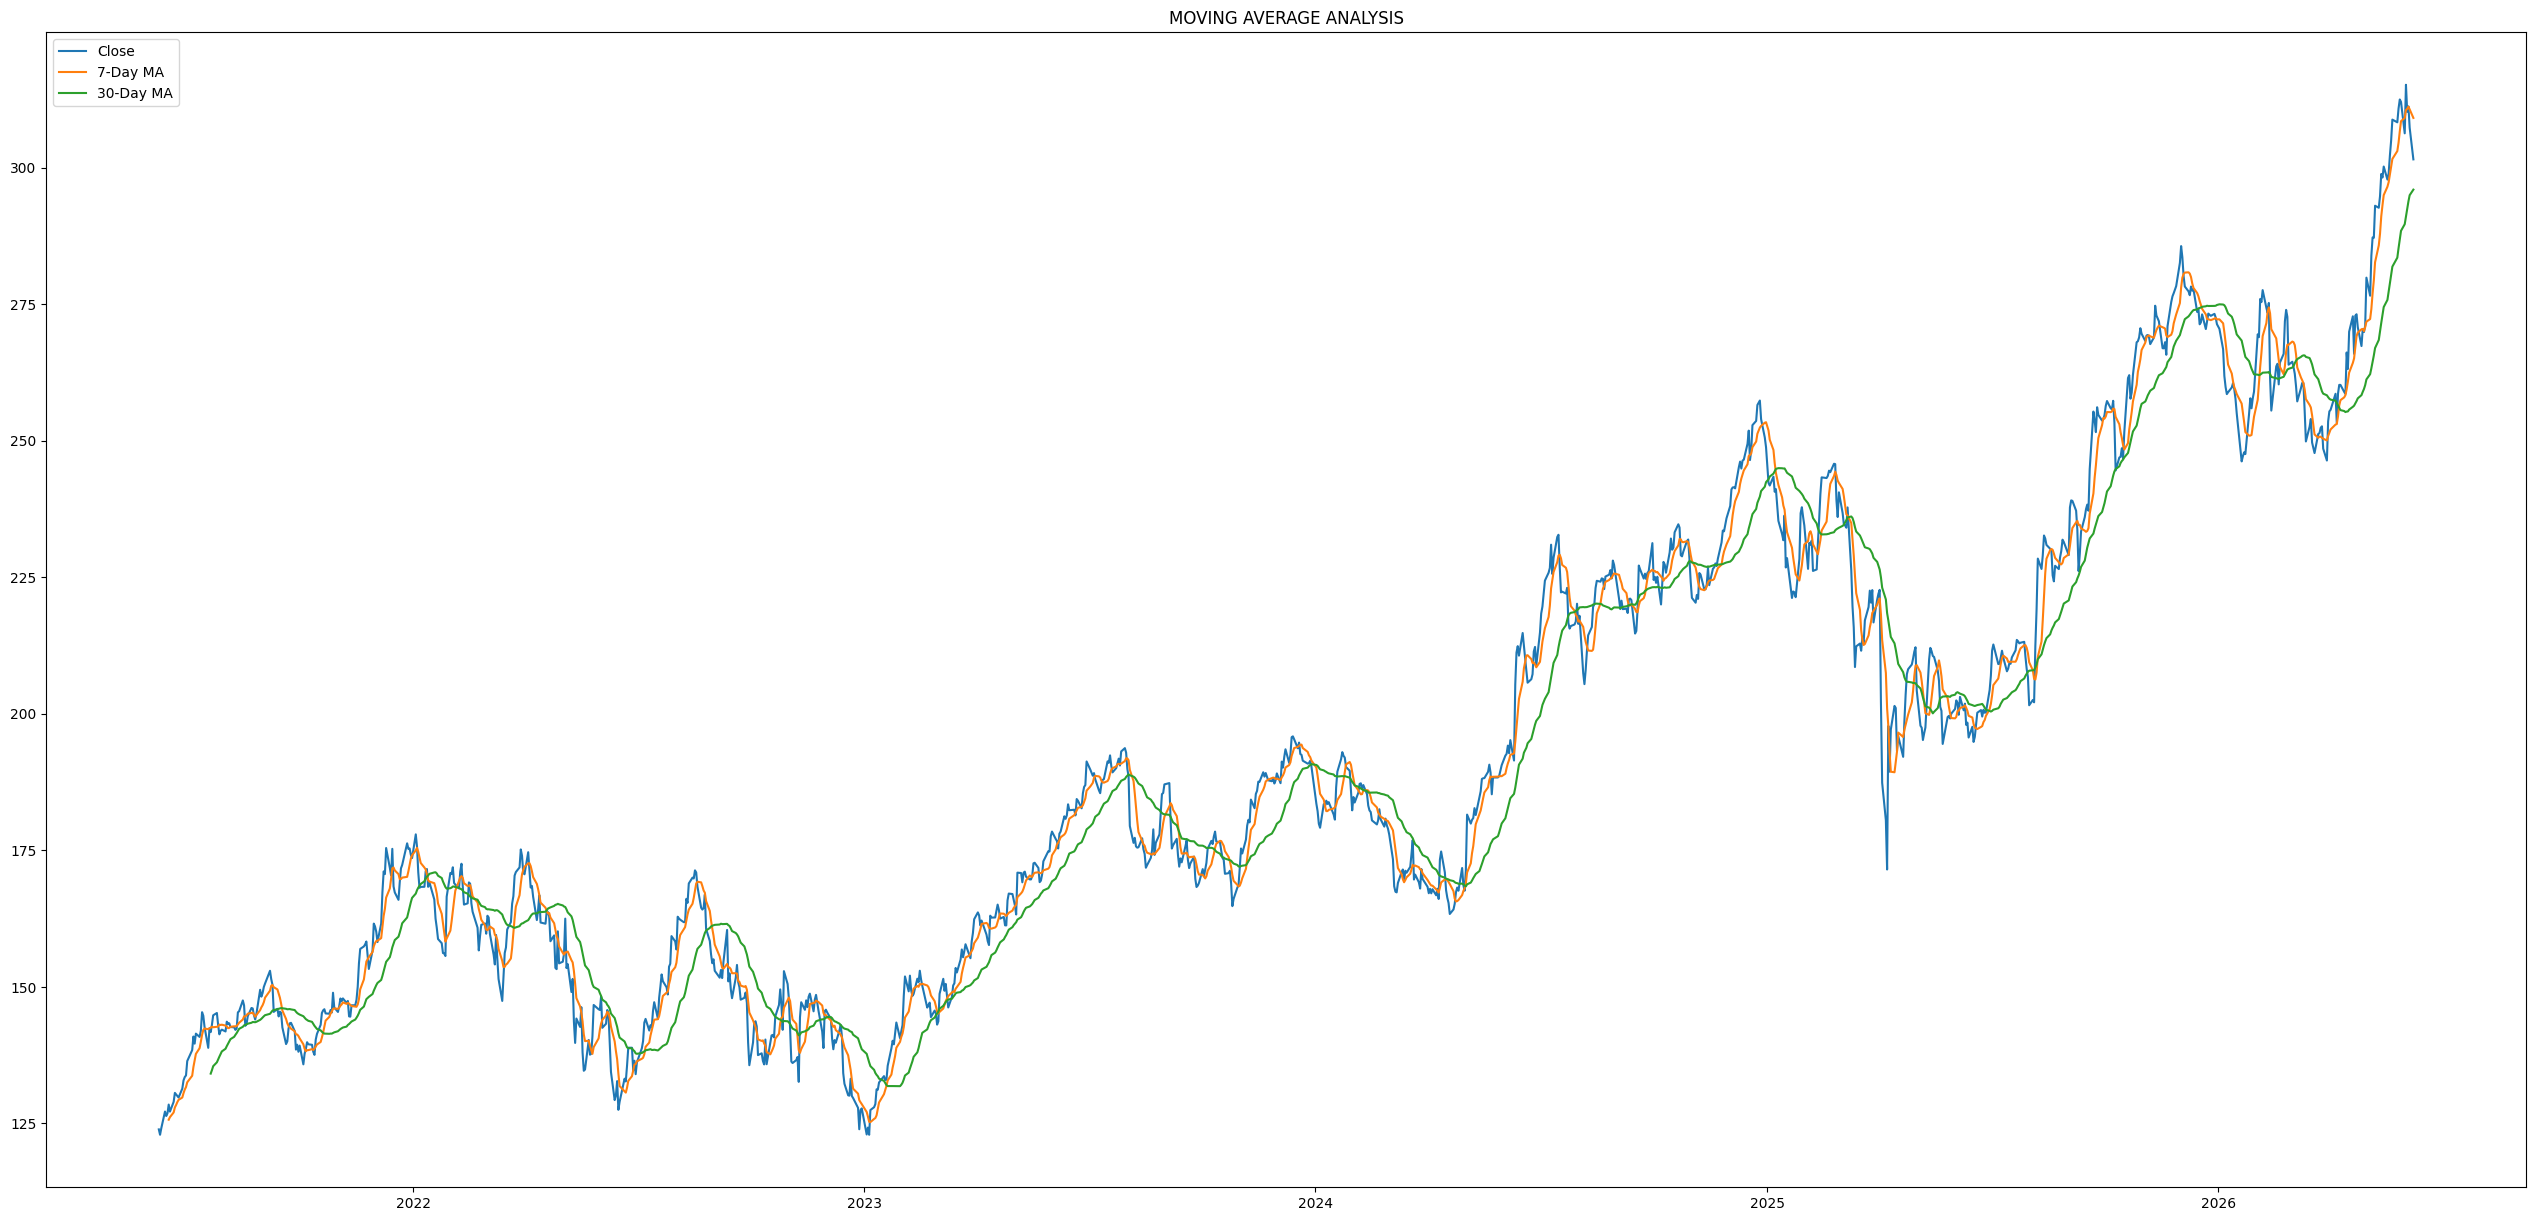

In [117]:
plt.figure(figsize=(32,15))
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["MA_7"], label="7-Day MA")
plt.plot(df.index, df["MA_30"], label="30-Day MA")
plt.legend()
plt.title("MOVING AVERAGE ANALYSIS")
plt.show()

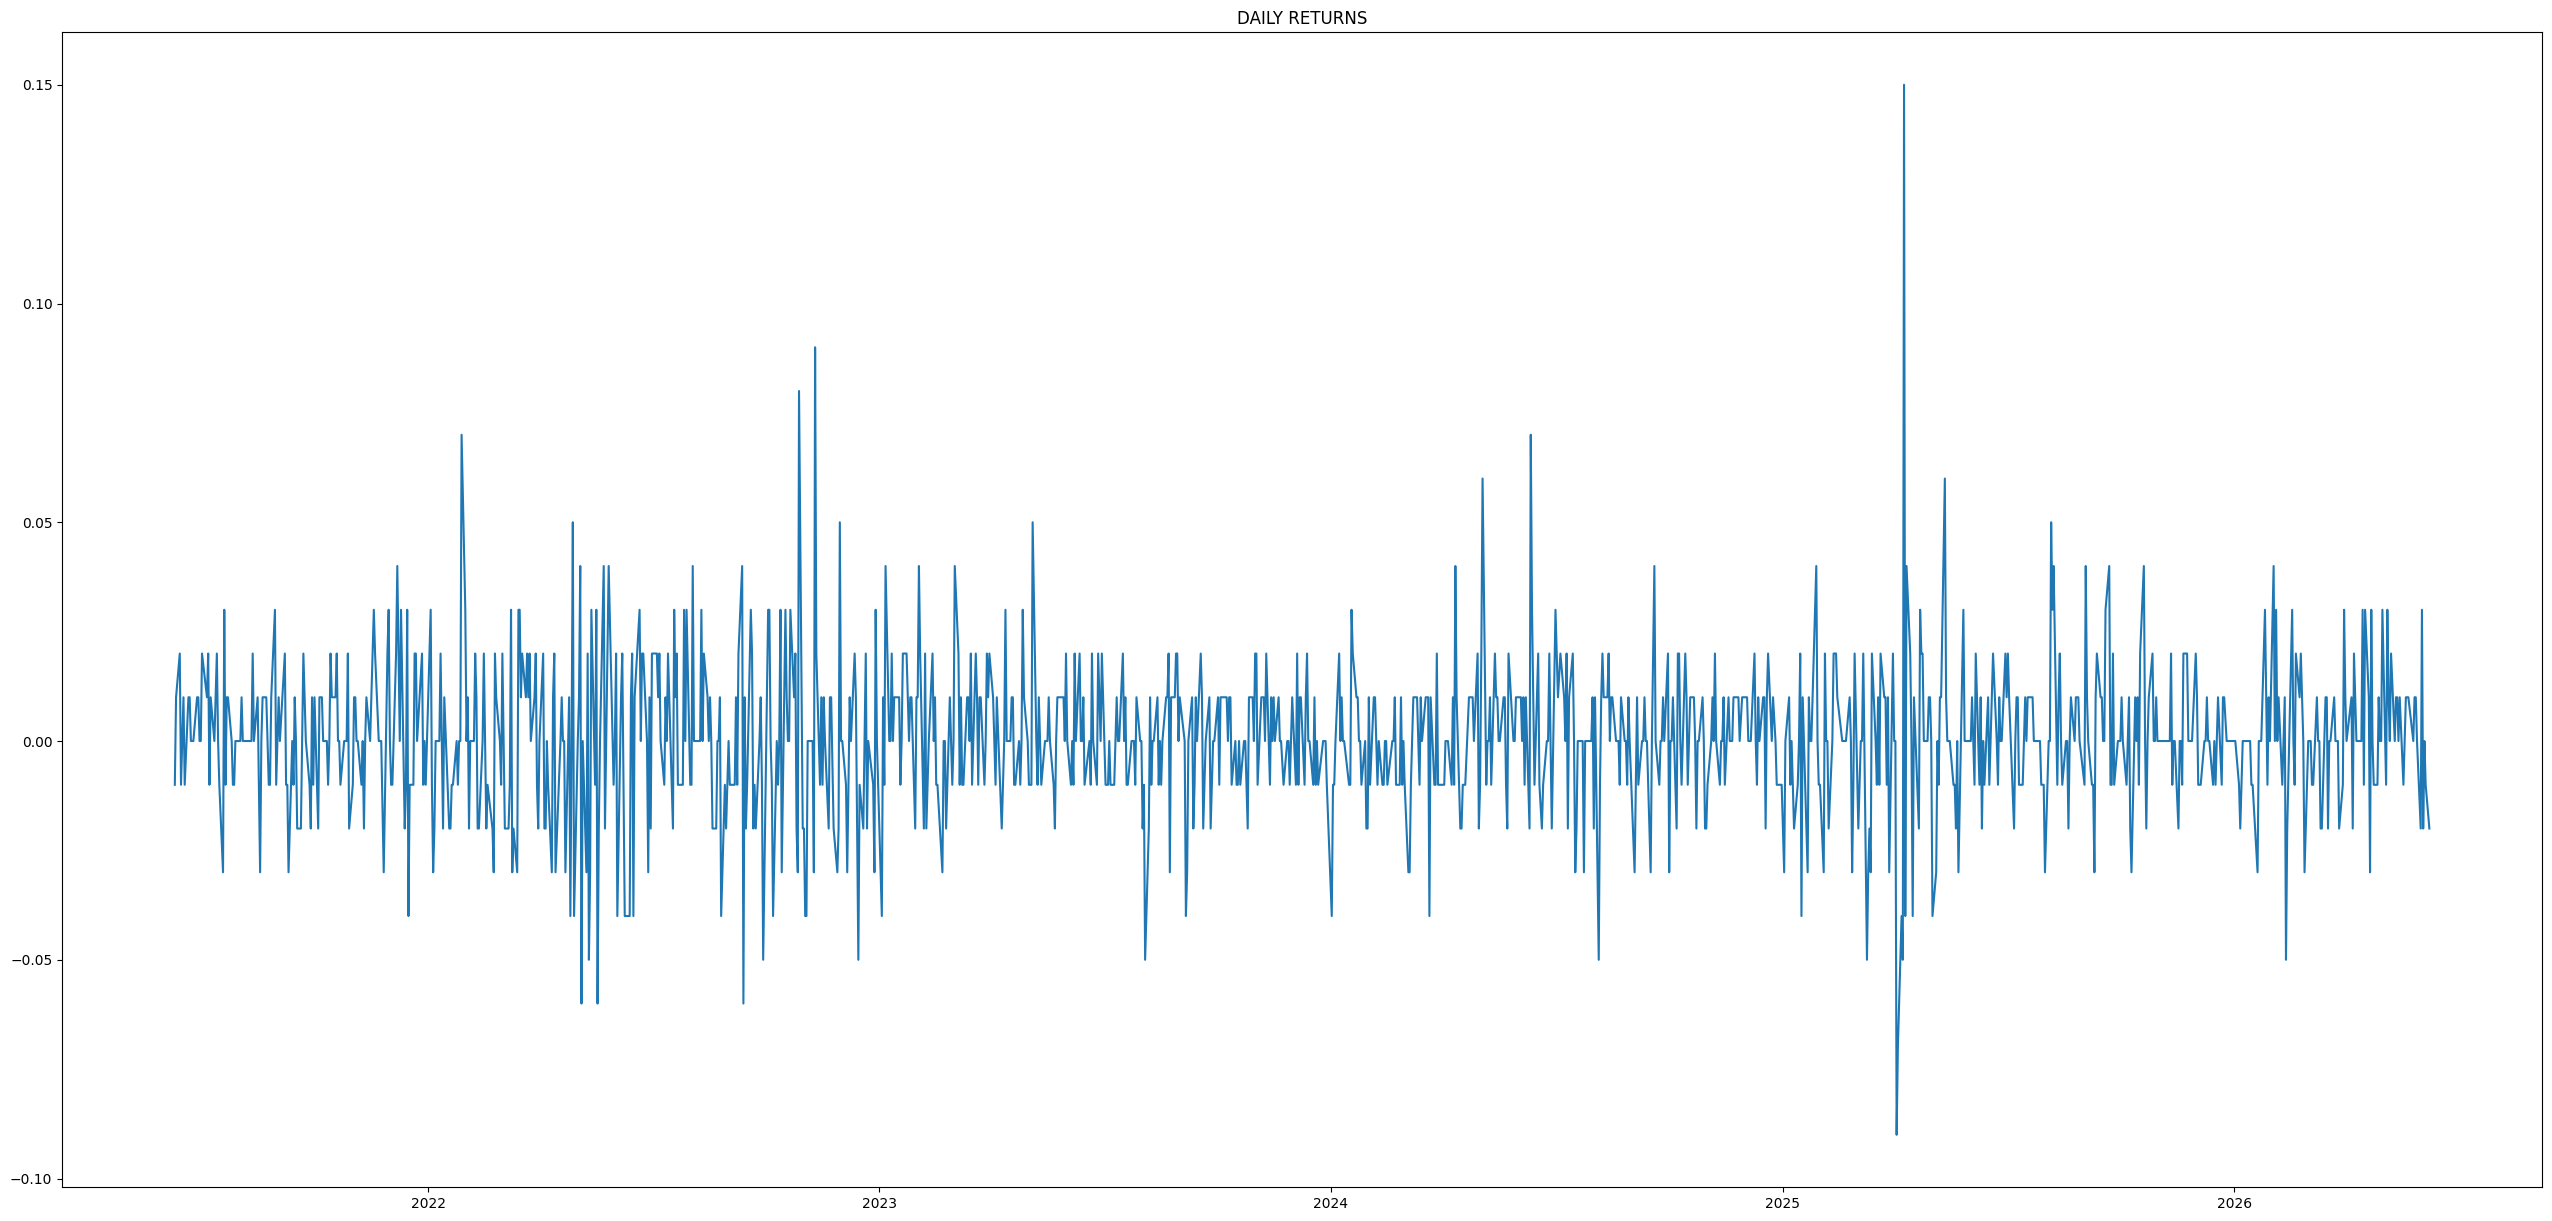

In [119]:
plt.figure(figsize=(32,5))
plt.plot(df.index, df["Daily Return"])
plt.title("DAILY RETURNS")

plt.show()

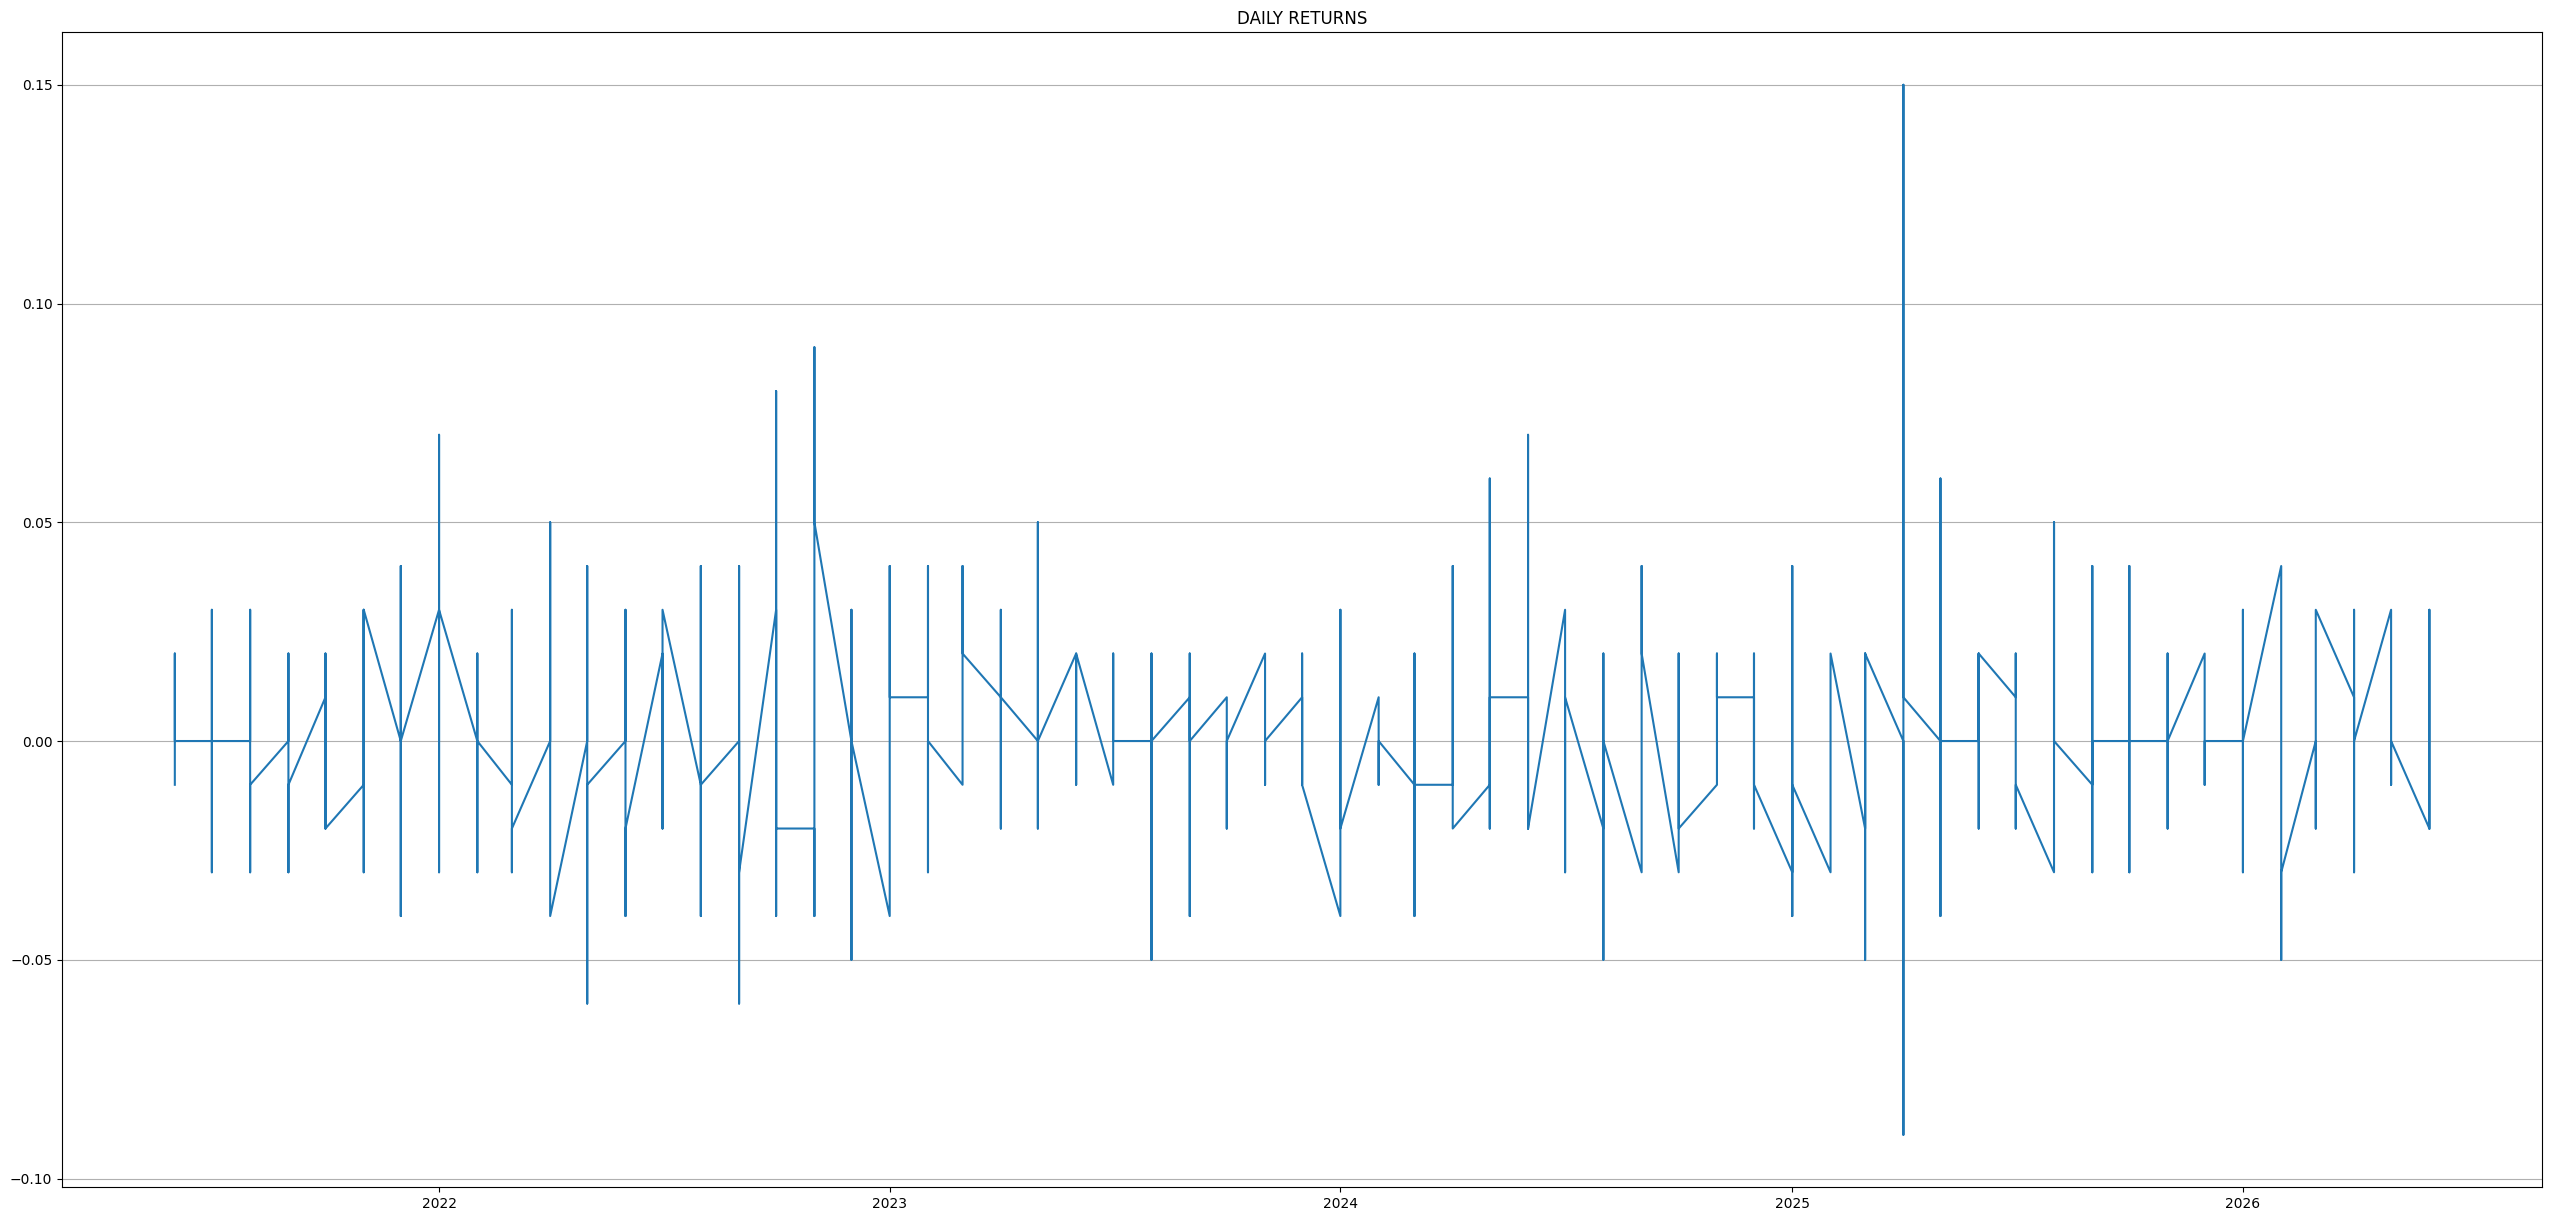

In [120]:
plt.figure(figsize=(32,15))
plt.plot(df["Year Month"], df["Daily Return"])
plt.title("DAILY RETURNS")
plt.grid(axis="y")
plt.show()

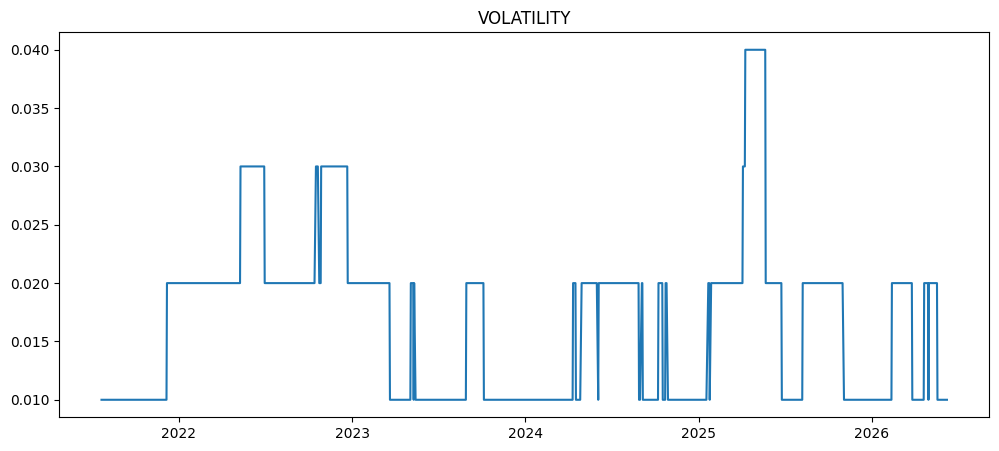

In [121]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Volatility"])
plt.title("VOLATILITY")
plt.show()